# Функциональная связность между каналами ЭЭГ Олега

Этот ноутбук анализирует функциональную связность между каналами ЭЭГ на основе когерентности (`coherence`) с помощью `spectral_connectivity_epochs` из MNE.

Что делает ноутбук:

1. Загружает очищенные EDF-файлы из папки `cleaned_data/`
2. Для каждого состояния считает когерентность между всеми парами каналов:
   - `O1`, `T3`, `Fp1`, `Fp2`, `T4`, `O2`
3. Строит три типа визуализаций:
   - тепловые карты средней связности между каналами
   - столбчатый график средней связности по частотным полосам
   - разностные матрицы относительно подходящего эталона
4. Использует два эталона:
   - открытые глаза
   - закрытые глаза
5. Для каждого состояния показывает, как изменилась связность относительно соответствующего эталона

Частотные полосы:

- Delta: 1–4 Гц
- Theta: 4–8 Гц
- Alpha: 8–13 Гц
- Beta: 13–30 Гц
- Gamma: 30–48 Гц

Примечание:
состояние `7 Изнутри (16 сек)` очень короткое, поэтому оценка связности для него будет менее надёжной и должна интерпретироваться осторожно.


In [16]:
from pathlib import Path
import math
import mne
import numpy as np
import matplotlib.pyplot as plt
from mne_connectivity import spectral_connectivity_epochs


In [17]:
# Cell 2 — Настройки

CLEAN_DIR = Path("cleaned_data")

FILES = {
    "1 open eyes_clean.edf":               "1 Открытые (эталон)",
    "2 closed eyes_clean.edf":             "2 Закрытые (эталон)",
    "3 2026.01.24-16.16.21.085_clean.edf": "3 Слабый поток открытые",
    "4 2026.01.24-16.18.47.499_clean.edf": "4 Слабый поток закрытые",
    "5 2026.01.24-16.38.37.757_clean.edf": "5 Мощный поток закрытые",
    "6 2026.01.24-16.41.01.794_clean.edf": "6 Мощный поток открытые",
    "7 2026.01.24-16.53.06.041_clean.edf": "7 Изнутри (16 сек)",
    "8 2026.01.24-17.03.42.427_clean.edf": "8 Медитация внутрь себя",
    "9 2026.01.24-17.05.59.615_clean.edf": "9 Исчезновение ощущения себя",
}

CHANNELS = ["O1", "T3", "Fp1", "Fp2", "T4", "O2"]

BANDS = {
    "Delta 1–4":   (1, 4),
    "Theta 4–8":   (4, 8),
    "Alpha 8–13":  (8, 13),
    "Beta 13–30":  (13, 30),
    "Gamma 30–48": (30, 48),
}

EPOCH_SEC = 5


In [18]:
# Cell 3 — Функции для подготовки эпох и расчета связности

def make_epochs(raw, epoch_sec=5):
    """
    Нарезает непрерывную запись на эпохи фиксированной длины.
    Если запись короткая, используется одна эпоха на всю длину.
    """
    sfreq = raw.info["sfreq"]
    duration = raw.times[-1]
    n_epochs = math.floor(duration / epoch_sec)

    if n_epochs < 2:
        events = np.array([[0, 0, 1]])
        tmax = duration - 1 / sfreq
    else:
        onsets = [int(i * epoch_sec * sfreq) for i in range(n_epochs)]
        events = np.column_stack([
            onsets,
            np.zeros(n_epochs, dtype=int),
            np.ones(n_epochs, dtype=int)
        ])
        tmax = epoch_sec - 1 / sfreq

    picks = mne.pick_channels(raw.info["ch_names"], include=CHANNELS)

    epochs = mne.Epochs(
        raw,
        events,
        tmin=0,
        tmax=tmax,
        picks=picks,
        baseline=None,
        preload=True,
        verbose=False
    )
    return epochs


def compute_connectivity(raw, bands):
    """
    Считает когерентность между всеми парами каналов
    отдельно в каждой полосе.
    Возвращает словарь:
    {band_name: matrix 6x6}
    """
    epochs = make_epochs(raw, epoch_sec=EPOCH_SEC)
    sfreq = raw.info["sfreq"]
    result = {}

    for band_name, (fmin, fmax) in bands.items():
        con_obj = spectral_connectivity_epochs(
            epochs,
            method="coh",
            mode="fourier",
            sfreq=sfreq,
            fmin=fmin,
            fmax=fmax,
            faverage=True,
            verbose=False,
        )

        con_data = con_obj.get_data(output="dense")[:, :, 0]
        result[band_name] = con_data

    return result


In [19]:
# Cell 4 — Вспомогательные функции для усреднения

def mean_connectivity(con_dict):
    """
    Средняя когерентность по всем полосам и всем парам каналов.
    """
    all_vals = []
    for mat in con_dict.values():
        idx = np.triu_indices(mat.shape[0], k=1)
        all_vals.extend(mat[idx].tolist())
    return np.mean(all_vals) if all_vals else 0.0


def band_mean(con_mat):
    """
    Средняя когерентность по всем парам каналов
    внутри одной матрицы.
    """
    idx = np.triu_indices(con_mat.shape[0], k=1)
    vals = con_mat[idx]
    vals = vals[~np.isnan(vals)]
    return float(np.mean(vals)) if len(vals) else 0.0



In [20]:
# Cell 5 — Загрузка файлов и расчет связности

print("Считаю связность...")
conn_data = {}

for filename, label in FILES.items():
    path = CLEAN_DIR / filename

    if not path.exists():
        print(f"  [!] Не найден: {filename}")
        continue

    raw = mne.io.read_raw_edf(path, preload=True, verbose=False)
    conn_data[label] = compute_connectivity(raw, BANDS)
    print(f"  ✓ {label}")

if not conn_data:
    raise FileNotFoundError("Не удалось загрузить ни одного EDF-файла из папки cleaned_data.")

labels = list(conn_data.keys())
band_names = list(BANDS.keys())
n_states = len(labels)

print("\nГотово.")
print("Количество состояний:", n_states)


Считаю связность...
  ✓ 1 Открытые (эталон)
  ✓ 2 Закрытые (эталон)
  ✓ 3 Слабый поток открытые
  ✓ 4 Слабый поток закрытые
  ✓ 5 Мощный поток закрытые
  ✓ 6 Мощный поток открытые
  ✓ 7 Изнутри (16 сек)
  ✓ 8 Медитация внутрь себя
  ✓ 9 Исчезновение ощущения себя

Готово.
Количество состояний: 9


In [21]:
# Cell 6 — Усредненные матрицы связности по всем полосам

avg_matrices = {}

for lbl in labels:
    stack = np.stack(list(conn_data[lbl].values()), axis=0)
    avg_matrices[lbl] = np.mean(stack, axis=0)


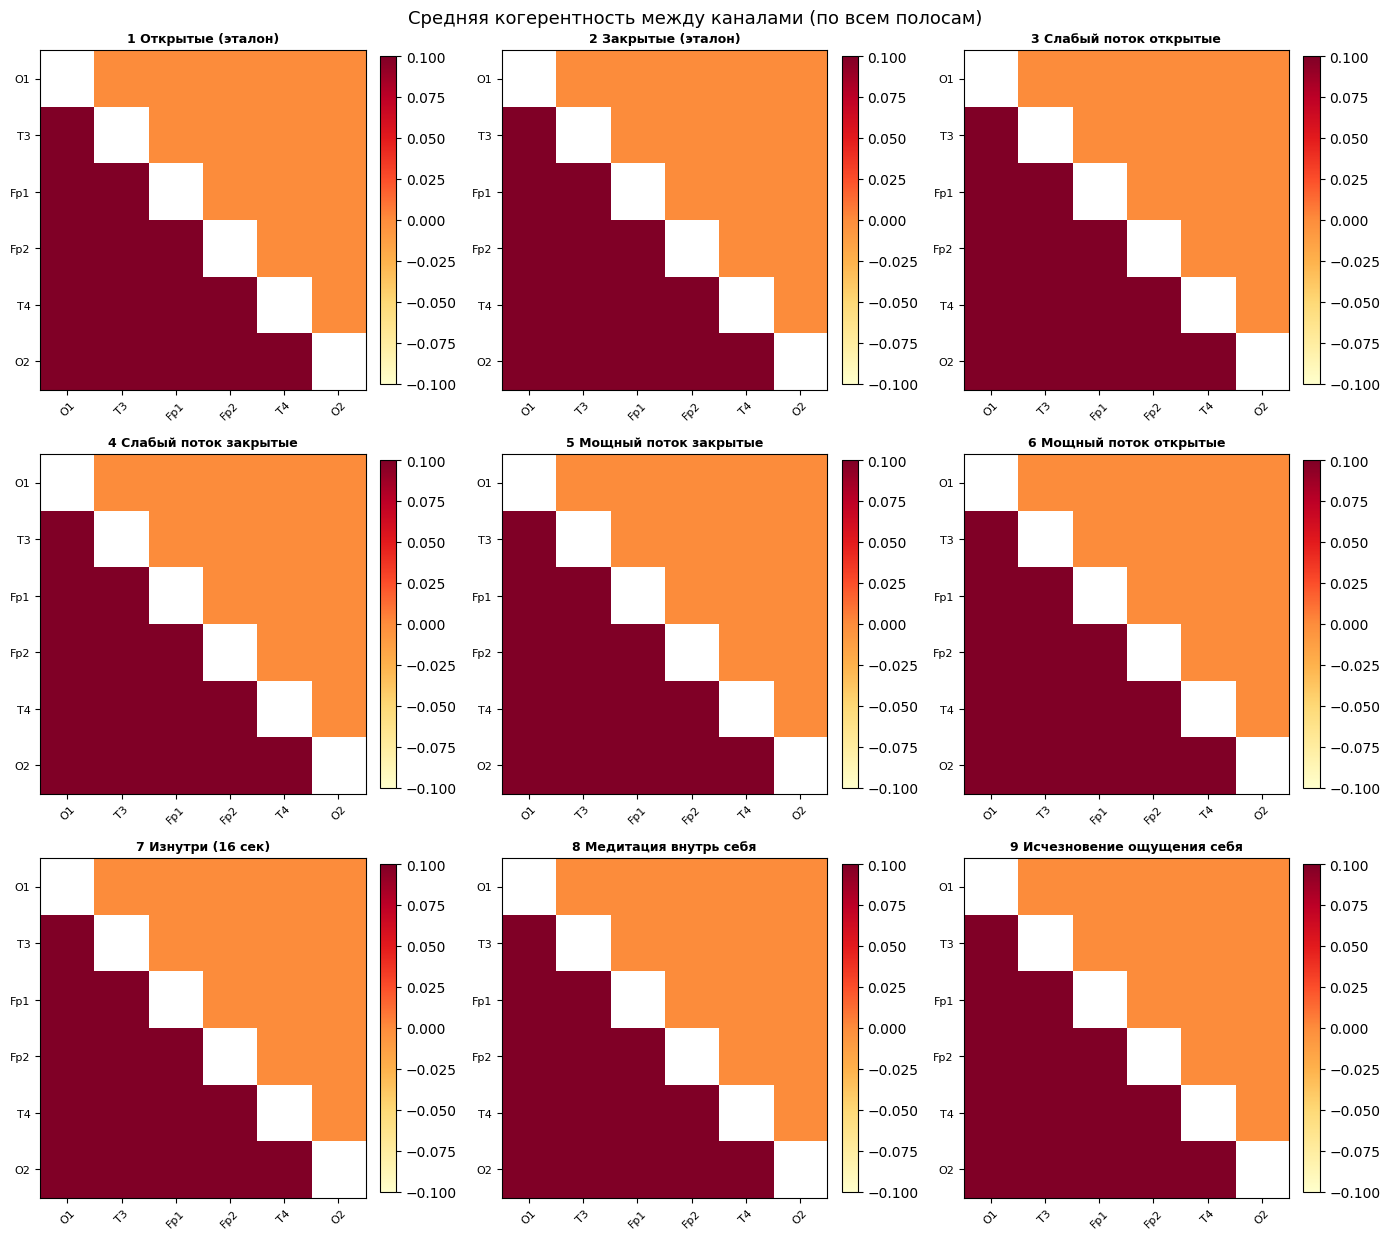

Сохранено: oleg_connectivity_heatmaps.png


In [22]:
# Cell 7 — График 1: тепловые карты средней связности

n_cols = 3
n_rows = math.ceil(n_states / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4.2))
axes = axes.flatten()

vmin = min(m[np.triu_indices(6, k=1)].min() for m in avg_matrices.values())
vmax = max(m[np.triu_indices(6, k=1)].max() for m in avg_matrices.values())

for i, lbl in enumerate(labels):
    ax = axes[i]
    mat = avg_matrices[lbl].copy()
    np.fill_diagonal(mat, np.nan)

    im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="YlOrRd", aspect="auto")
    ax.set_title(lbl, fontsize=9, fontweight="bold")
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(CHANNELS, fontsize=8, rotation=45)
    ax.set_yticklabels(CHANNELS, fontsize=8)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for j in range(n_states, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Средняя когерентность между каналами (по всем полосам)", fontsize=13)
plt.tight_layout()
plt.savefig("oleg_connectivity_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено: oleg_connectivity_heatmaps.png")


In [23]:
# Cell 8 — Подготовка данных для графика по полосам

band_matrix = np.array([
    [band_mean(conn_data[lbl][b]) for b in band_names]
    for lbl in labels
])

STATE_COLORS = [
    "#888888", "#555555",
    "#4C9BE8", "#3A7FD4",
    "#E8834C", "#D4673A",
    "#6DC06A", "#4DA84A",
    "#A855C8",
]

colors = STATE_COLORS[:n_states]


In [24]:
print("band_matrix shape:", band_matrix.shape)
print(band_matrix)

for lbl in labels:
    print("\n", lbl)
    for b in band_names:
        mat = conn_data[lbl][b]
        idx = np.triu_indices(mat.shape[0], k=1)
        vals = mat[idx]
        print(
            b,
            "min=", np.nanmin(vals),
            "max=", np.nanmax(vals),
            "mean=", np.nanmean(vals),
            "n_nan=", np.isnan(vals).sum()
        )


band_matrix shape: (9, 5)
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

 1 Открытые (эталон)
Delta 1–4 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Theta 4–8 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Alpha 8–13 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Beta 13–30 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Gamma 30–48 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0

 2 Закрытые (эталон)
Delta 1–4 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Theta 4–8 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Alpha 8–13 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Beta 13–30 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Gamma 30–48 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0

 3 Слабый поток открытые
Delta 1–4 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Theta 4–8 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Alpha 8–13 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Beta 13–30 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0
Gamma 30–48 min= 0.0 max= 0.0 mean= 0.0 n_nan= 0

 4 Слабый поток закрыты

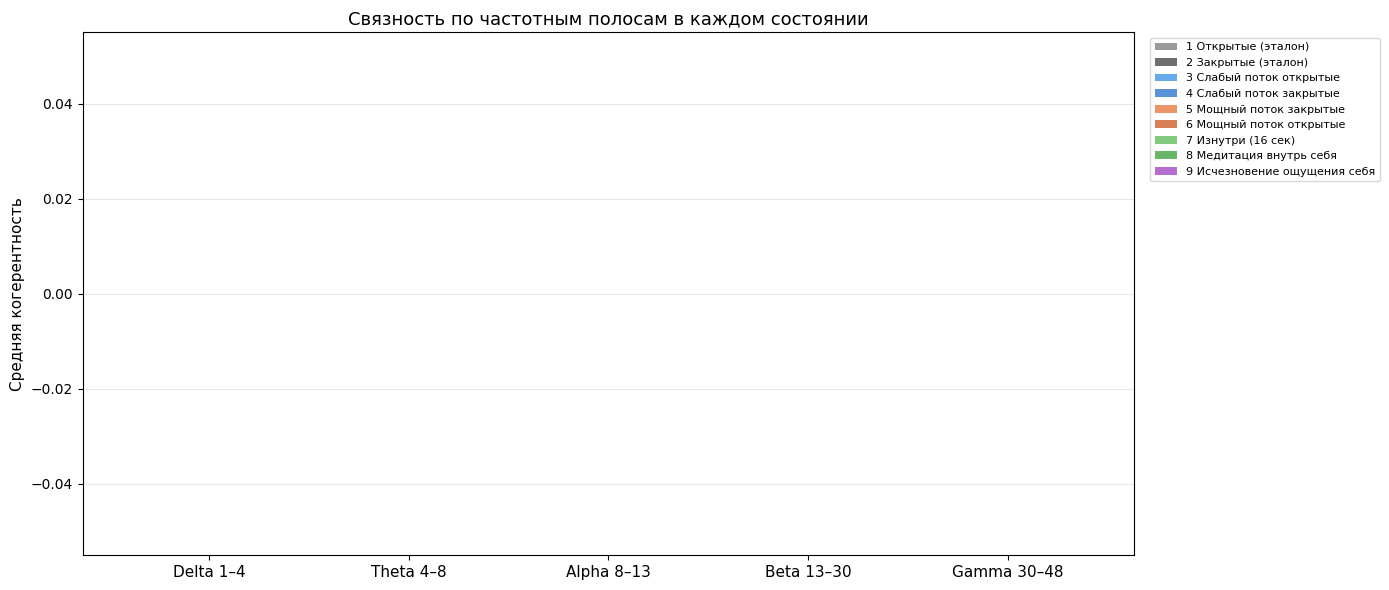

Сохранено: oleg_connectivity_bands.png


In [25]:
# Cell 9 — График 2: средняя связность по полосам

x = np.arange(len(band_names))
width = 0.8 / n_states

fig, ax = plt.subplots(figsize=(14, 6))

for i, (lbl, col) in enumerate(zip(labels, colors)):
    offset = (i - n_states / 2 + 0.5) * width
    ax.bar(
        x + offset,
        band_matrix[i],
        width=width * 0.9,
        color=col,
        alpha=0.85,
        label=lbl
    )

ax.set_xticks(x)
ax.set_xticklabels(band_names, fontsize=11)
ax.set_ylabel("Средняя когерентность", fontsize=11)
ax.set_title("Связность по частотным полосам в каждом состоянии", fontsize=13)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("oleg_connectivity_bands.png", dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено: oleg_connectivity_bands.png")


In [26]:
# Cell 10 — Эталоны и карта соответствия

ref_open = avg_matrices.get("1 Открытые (эталон)")
ref_closed = avg_matrices.get("2 Закрытые (эталон)")

REFERENCE_MAP = {
    "3 Слабый поток открытые":      ref_open,
    "4 Слабый поток закрытые":      ref_closed,
    "5 Мощный поток закрытые":      ref_closed,
    "6 Мощный поток открытые":      ref_open,
    "7 Изнутри (16 сек)":           ref_open,
    "8 Медитация внутрь себя":      ref_closed,
    "9 Исчезновение ощущения себя": ref_closed,
}

diff_labels = [
    lbl for lbl in labels
    if lbl in REFERENCE_MAP and REFERENCE_MAP[lbl] is not None
]

if not diff_labels:
    raise ValueError("Не удалось сформировать список состояний для сравнения с эталонами.")


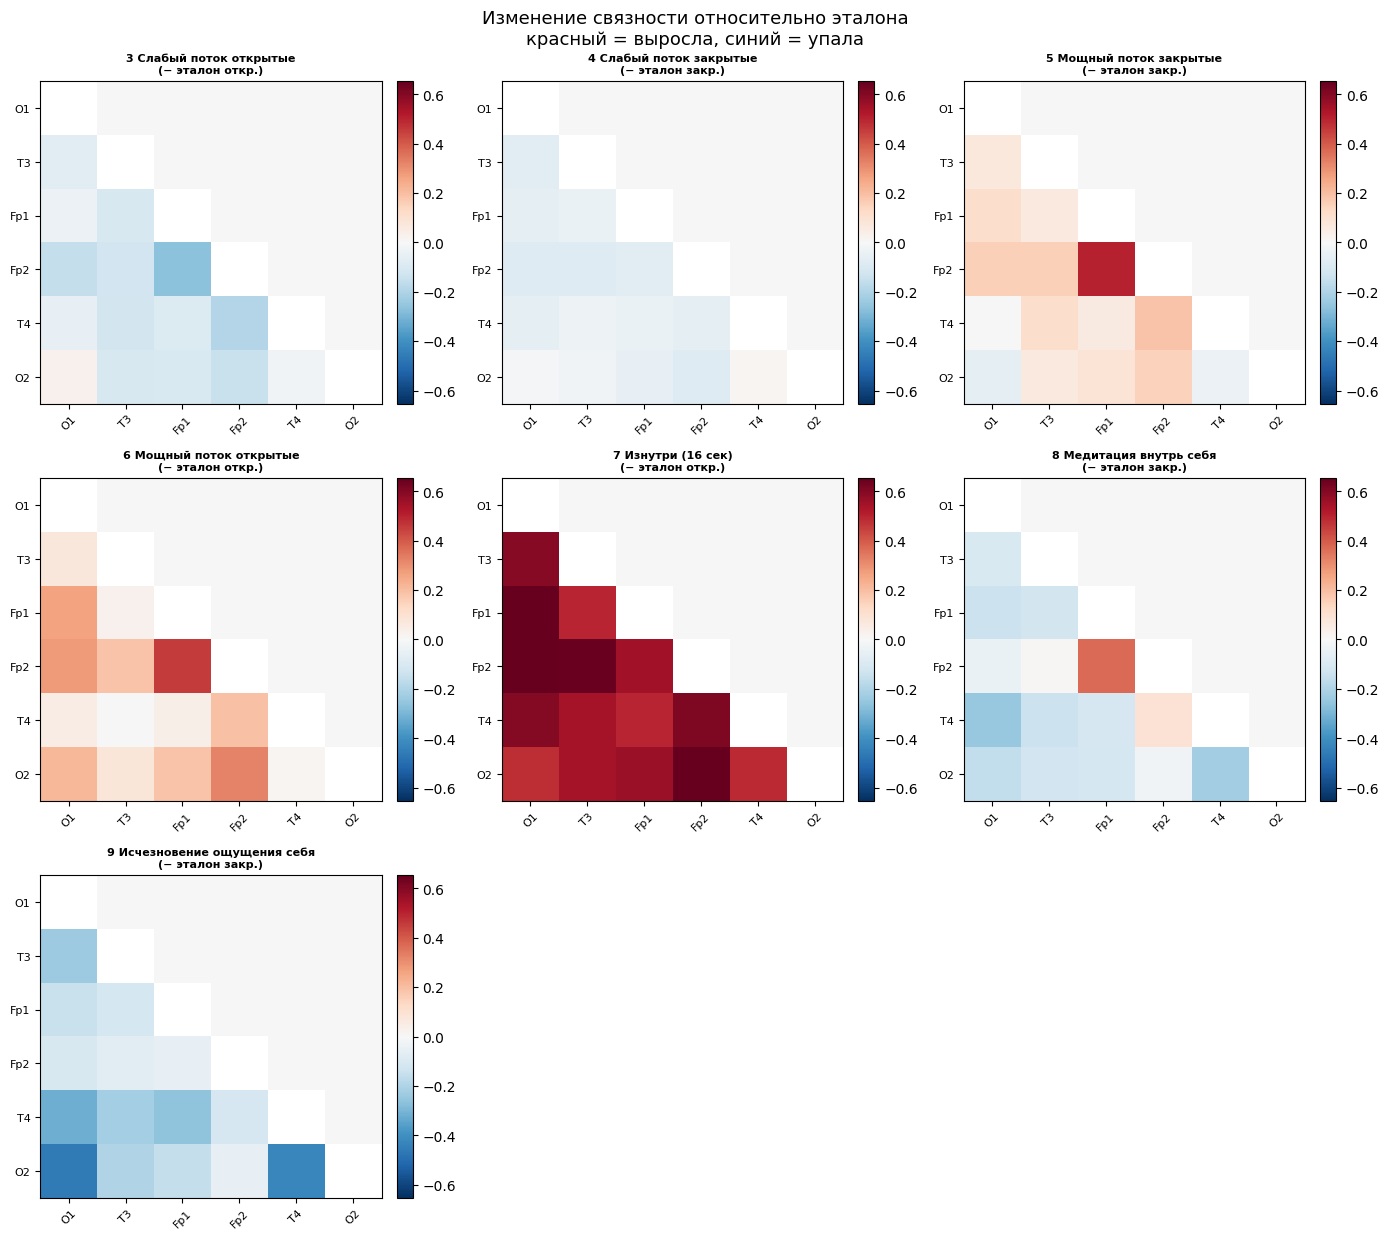

Сохранено: oleg_connectivity_diff.png


In [27]:
# Cell 11 — График 3: разностные матрицы относительно эталона

n_diff = len(diff_labels)
n_cols_d = 3
n_rows_d = math.ceil(n_diff / n_cols_d)

fig, axes = plt.subplots(n_rows_d, n_cols_d, figsize=(14, n_rows_d * 4.2))
axes = axes.flatten()

diffs = [avg_matrices[lbl] - REFERENCE_MAP[lbl] for lbl in diff_labels]
abs_max = max(np.nanmax(np.abs(d)) for d in diffs)

for i, lbl in enumerate(diff_labels):
    ax = axes[i]
    diff = avg_matrices[lbl] - REFERENCE_MAP[lbl]
    np.fill_diagonal(diff, np.nan)

    im = ax.imshow(
        diff,
        vmin=-abs_max,
        vmax=abs_max,
        cmap="RdBu_r",
        aspect="auto"
    )

    ref_name = "эталон откр." if REFERENCE_MAP[lbl] is ref_open else "эталон закр."
    ax.set_title(f"{lbl}\n(− {ref_name})", fontsize=8, fontweight="bold")
    ax.set_xticks(range(6))
    ax.set_yticks(range(6))
    ax.set_xticklabels(CHANNELS, fontsize=8, rotation=45)
    ax.set_yticklabels(CHANNELS, fontsize=8)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for j in range(n_diff, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    "Изменение связности относительно эталона\nкрасный = выросла, синий = упала",
    fontsize=13
)
plt.tight_layout()
plt.savefig("oleg_connectivity_diff.png", dpi=150, bbox_inches="tight")
plt.show()

print("Сохранено: oleg_connectivity_diff.png")


In [28]:
# Cell 12 — Сводная таблица в терминале

print("── Средняя связность по состояниям ──")
print(f"{'Состояние':<38} {'Связность':>10}")
print("─" * 50)

all_means = [mean_connectivity(conn_data[lbl]) for lbl in labels]
global_mean = np.mean(all_means) if all_means else 0.0

for lbl in labels:
    val = mean_connectivity(conn_data[lbl])
    marker = " ◄" if val > global_mean * 1.2 else ""
    print(f"{lbl:<38} {val:>10.4f}{marker}")

print("\n◄ = заметно выше средней по всем состояниям")


── Средняя связность по состояниям ──
Состояние                               Связность
──────────────────────────────────────────────────
1 Открытые (эталон)                        0.0000
2 Закрытые (эталон)                        0.0000
3 Слабый поток открытые                    0.0000
4 Слабый поток закрытые                    0.0000
5 Мощный поток закрытые                    0.0000
6 Мощный поток открытые                    0.0000
7 Изнутри (16 сек)                         0.0000
8 Медитация внутрь себя                    0.0000
9 Исчезновение ощущения себя               0.0000

◄ = заметно выше средней по всем состояниям
